# 这个部分我们试着复现一下论文中提到的可微分位置模拟/姿态反解/旋转矩阵返回/位移矩阵返回。

# 坐标系定义与转换

为了符合机器人领域的通用标准并便于后续与 ROS 生态结合，本项目将弃用参考项目的坐标系，转而采用 **ROS 标准坐标系 (REP 103)** 进行动力学解算。

## 1. 动力学解算坐标系 (ROS Standard)

*   **世界坐标系 (World Frame)**: **ENU** (East-North-Up)
    *   **+X**: 东 (East)
    *   **+Y**: 北 (North)
    *   **+Z**: 天 (Up) - 重力方向为 -Z
*   **机体坐标系 (Body Frame)**: **FLU** (Forward-Left-Up)
    *   **+X**: 前 (Forward)
    *   **+Y**: 左 (Left)
    *   **+Z**: 上 (Up)

## 2. 渲染坐标系 (PyTorch3D)

PyTorch3D 使用的坐标系定义如下（用于后续渲染转换）：
*   **+X**: 向左 (Left)
*   **+Y**: 向上 (Up)
*   **+Z**: 向里 (In / Screen)

在将动力学状态传递给渲染器时，我们需要进行坐标系变换 (ROS -> PyTorch3D)。

## 3. 相机在那里？
*   **相机放在机体中心正前方10cm处，X=0.10，Y=0,Z=0**

In [1]:
# 计算机体Z轴
import torch
import math

# 检查设备
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# ==========================================
# 坐标系定义 (采用 ROS 标准 REP 103)
# ==========================================
# 世界坐标系 (World): ENU (East-North-Up) -> X:东, Y:北, Z:上
# 机体坐标系 (Body): FLU (Forward-Left-Up) -> X:前, Y:左, Z:上
# ==========================================

# 1. 重力定义
# 在 ENU 世界坐标系下，重力加速度向下，即 Z 轴负方向
g_world = torch.tensor([0.0, 0.0, -9.81], device=device)

# 2. 推力定义
# 推力通常沿机体 Z 轴向上产生
thrust_acc_mag = 15.0  # 推力产生的加速度大小 (m/s^2)
a_thrust_body = torch.tensor([0.0, 0.0, thrust_acc_mag], device=device)

# 3. 姿态模拟 (旋转矩阵)
# 假设无人机有一个简单的姿态：例如水平悬停 (单位矩阵)
# R_body_to_world: 将向量从机体坐标系旋转到世界坐标系
R_body_to_world = torch.eye(3, device=device) 

# 4. 动力学方程
# a_world = R_b2w * a_body + g_world
a_thrust_world = R_body_to_world @ a_thrust_body
a_total_world = a_thrust_world + g_world

print(f"重力 (World): {g_world.tolist()}")
print(f"推力加速度 (Body): {a_thrust_body.tolist()}")
print(f"推力加速度 (World): {a_thrust_world.tolist()}")
print(f"合加速度 (World): {a_total_world.tolist()}")

重力 (World): [0.0, 0.0, -9.8100004196167]
推力加速度 (Body): [0.0, 0.0, 15.0]
推力加速度 (World): [0.0, 0.0, 15.0]
合加速度 (World): [0.0, 0.0, 5.189999580383301]


In [2]:
# 计算推力大小
thrust_magnitude = torch.norm(a_thrust_body)
print(f"推力大小: {thrust_magnitude} ")
# 计算机体Z轴
z_b = a_thrust_body / thrust_magnitude
print(f"机体Z轴 (Body): {z_b.tolist()}")
# 换个测试推力向量
a_thrust_body = torch.tensor([3.0, 4.0, 12.0], device=device)
#z_b_test 
z_b_test = a_thrust_body / torch.norm(a_thrust_body)
print(f"测试推力向量: {a_thrust_body}")
print(f"测试机体Z轴 (Body): {z_b_test}")

推力大小: 15.0 
机体Z轴 (Body): [0.0, 0.0, 1.0]
测试推力向量: tensor([ 3.,  4., 12.], device='cuda:0')
测试机体Z轴 (Body): tensor([0.2308, 0.3077, 0.9231], device='cuda:0')


In [3]:
# 确定机体X轴 (Forward Vector)
# 逻辑：混合“旧的机头朝向”与“当前速度方向”，并强制与 Z 轴垂直

# 1. 准备数据
# 假设上一时刻的旋转矩阵 R_old 为当前的 R_body_to_world
R_old = R_body_to_world
# 假设预测速度 v_pred (在世界坐标系下)
v_pred = torch.tensor([2.0, 0.5, 0.0], device=device)
# 偏航惯性系数 (越大越保持原方向，模拟惯性)
yaw_inertia = 5.0

# 2. 获取旧的 X 轴
# R 的列向量分别是 X, Y, Z 轴
x_old = R_old[:, 0]

# 3. 混合旧朝向和速度方向
# 公式: f_temp = x_old * yaw_inertia + v_pred
f_temp = x_old * yaw_inertia + v_pred

# 4. 正交化 (Orthogonalization)
# 使得新的 X 轴垂直于 Z 轴 (z_b_test)
# 核心约束: x_new . z_b = 0
# 算法采用保留 X, Y 分量，调整 Z 分量的方法:
# fx*ux + fy*uy + fz*uz = 0  =>  fz = -(fx*ux + fy*uy) / uz
ux, uy, uz = z_b_test[0], z_b_test[1], z_b_test[2]
fx, fy = f_temp[0], f_temp[1]

# 注意：如果 uz 接近 0 (机体 Z 轴水平)，这个除法会不稳定。
# 但在多旋翼正常飞行姿态中，Z 轴通常接近垂直，uz 较大。
fz_new = -(fx * ux + fy * uy) / uz

x_new_unnormalized = torch.tensor([fx, fy, fz_new], device=device)

# 5. 归一化
x_new = x_new_unnormalized / torch.norm(x_new_unnormalized)

print(f"旧 X 轴: {x_old.tolist()}")
print(f"速度方向: {v_pred.tolist()}")
print(f"新 X 轴 (Body Forward): {x_new.tolist()}")

# 6. 计算 Y 轴 (Body Left)
# y = z cross x (右手定则)
y_new = torch.cross(z_b_test, x_new)
print(f"新 Y 轴 (Body Left): {y_new.tolist()}")

# 7. 验证正交性
print(f"X . Z (应为0): {torch.dot(x_new, z_b_test).item():.6f}")
print(f"X . Y (应为0): {torch.dot(x_new, y_new).item():.6f}")

# 8. 组合新的旋转矩阵
R_new = torch.stack([x_new, y_new, z_b_test], dim=1)
print("新的旋转矩阵 R_new:\n", R_new)

旧 X 轴: [1.0, 0.0, 0.0]
速度方向: [2.0, 0.5, 0.0]
新 X 轴 (Body Forward): [0.9622176289558411, 0.06872983276844025, -0.2634643614292145]
新 Y 轴 (Body Left): [-0.14450888335704803, 0.949000358581543, -0.28020623326301575]
X . Z (应为0): -0.000000
X . Y (应为0): -0.000000
新的旋转矩阵 R_new:
 tensor([[ 0.9622, -0.1445,  0.2308],
        [ 0.0687,  0.9490,  0.3077],
        [-0.2635, -0.2802,  0.9231]], device='cuda:0')


/tmp/ipykernel_5605/3927379281.py:43: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789114325/work/aten/src/ATen/native/Cross.cpp:62.)
  y_new = torch.cross(z_b_test, x_new)


In [4]:
# 做个代码清理
# 假设一个期望加速度 
a_thrust_body = torch.tensor([0,0,15.0], device=device)  # 期望沿机体Z轴向上15 m/s^2
a_total = R_body_to_world @ a_thrust_body + g_world
print(f"清理后合加速度 (World): {a_total.tolist()}")



清理后合加速度 (World): [0.0, 0.0, 5.189999580383301]


## 3. 姿态反解函数封装

基于上述测试逻辑，我们将姿态反解过程封装为通用函数 `solve_attitude_from_thrust_and_velocity`。
该函数的核心逻辑如下：
1.  **确定 Z 轴**: 由期望推力向量的方向决定。
2.  **确定 X 轴**: 混合上一时刻的机头朝向与当前速度方向，并强制正交化以垂直于 Z 轴。
3.  **确定 Y 轴**: 通过右手定则 ($Z \times X$) 计算。


In [5]:
# ==========================================
# 代码清理：封装为函数 (支持批量处理)
# ==========================================

def solve_attitude_from_thrust_and_velocity(
    thrust_vector: torch.Tensor, 
    velocity: torch.Tensor, 
    R_old: torch.Tensor, 
    yaw_inertia: float = 5.0,
    dt: float = 0.02,
    yaw_ctl_delay: float = 12.0 # 建议默认值 12.0 (DiffPhysDrone default)
) -> torch.Tensor:
    """
    根据期望推力向量和当前速度，反解机体姿态 (旋转矩阵)。
    支持单个输入或批量输入。
    
    Args:
        thrust_vector (torch.Tensor): 期望推力向量 (世界坐标系)，对应机体 Z 轴方向。Shape: (3,) or (B, 3)
        velocity (torch.Tensor): 指向目标的向量 (世界坐标系)，用于确定机头朝向。Shape: (3,) or (B, 3)
        R_old (torch.Tensor): 上一时刻的旋转矩阵 (Body to World)。Shape: (3, 3) or (B, 3, 3)
        yaw_inertia (float): 偏航惯性系数 (混合权重)。
        dt (float): 时间步长，用于计算平滑系数。
        yaw_ctl_delay (float): 偏航控制延迟/响应系数 (参考项目中的二级平滑参数)。
                               值越大响应越快 (alpha越小)。
        
    Returns:
        torch.Tensor: 新的旋转矩阵 R_new (Body to World)。Shape: (3, 3) or (B, 3, 3)
    """
    # 维度处理 (统一转为 Batch 模式)
    is_batch = True
    if thrust_vector.dim() == 1:
        is_batch = False
        thrust_vector = thrust_vector.unsqueeze(0) # [1, 3]
        velocity = velocity.unsqueeze(0)           # [1, 3]
        R_old = R_old.unsqueeze(0)                 # [1, 3, 3]
        
    # 确定机体 Z 轴 (Body Up)
    # Z 轴方向即为推力方向
    # normalize dim=1 (across x,y,z)
    z_new = torch.nn.functional.normalize(thrust_vector, dim=1)
    
    # 确定机体 X 轴 (Body Forward)
    # 逻辑：混合“旧的机头朝向”与“当前速度方向”，并强制与 Z 轴垂直
    
    # 获取旧的 X 轴 (R 的第一列)
    # R_old: [B, 3, 3] -> R_old[:, :, 0]: [B, 3]
    x_old = R_old[:, :, 0]
    
    # [一级平滑/混合] 混合向量 (基于 yaw_inertia)
    # 参考项目 Update: forward_vec = forward_vec * yaw_inertia + v_pred
    # 物理含义: 风向标效应。速度越大，对机头朝向的修正力越大。
    # 不进行归一化，自然处理低速/悬停情况
    f_mixed_raw = x_old * yaw_inertia + velocity
    
    # 计算目标朝向 (Heading)
    target_heading = torch.nn.functional.normalize(f_mixed_raw, dim=1)
    
    # [二级平滑] Exponential Smoothing (参考项目逻辑)
    # alpha = exp(-delay * dt). delay 越大 (响应越快), alpha 越小, 结果越接近 target.
    # f_temp = target * (1 - alpha) + old * alpha
    alpha = math.exp(-yaw_ctl_delay * dt)
    f_temp = target_heading * (1 - alpha) + x_old * alpha
    
    # 正交化 (Orthogonalization)
    # 约束: x_new . z_new = 0  =>  fx*ux + fy*uy + fz*uz = 0
    # 解法: 保留 f_temp 的 x, y 分量，计算 fz
    ux, uy, uz = z_new[:, 0], z_new[:, 1], z_new[:, 2]
    fx, fy = f_temp[:, 0], f_temp[:, 1]
    
    # 准备结果容器
    fz_new = torch.zeros_like(fx)
    
    # 避免除以零 (当机体 Z 轴完全水平时，uz=0)
    mask_stable = torch.abs(uz) > 1e-6
    
    # 正常情况计算
    if mask_stable.any():
        fz_new[mask_stable] = -(fx[mask_stable] * ux[mask_stable] + fy[mask_stable] * uy[mask_stable]) / uz[mask_stable]
        
    x_new_unnormalized = torch.stack([fx, fy, fz_new], dim=1)
    
    # 备选方案：如果 Z 轴水平 (uz 接近 0)，使用旧的 Y 轴与 Z 轴叉乘得到 X 轴
    if not mask_stable.all():
        y_old = R_old[:, :, 1]
        # cross product
        x_fallback = torch.cross(y_old, z_new, dim=1)
        x_new_unnormalized[~mask_stable] = x_fallback[~mask_stable]
        
    # 归一化得到新的 X 轴
    x_new = torch.nn.functional.normalize(x_new_unnormalized, dim=1)
    
    # 确定机体 Y 轴 (Body Left)
    # 右手定则: y = z cross x
    y_new = torch.cross(z_new, x_new, dim=1)
    
    # 组合旋转矩阵
    # 列向量分别为 X, Y, Z -> stack dim=2
    R_new = torch.stack([x_new, y_new, z_new], dim=2)
    
    # 如果输入不是 batch，还原维度
    if not is_batch:
        return R_new.squeeze(0)
        
    return R_new

# ==========================================
# 测试封装后的函数 (Batch 测试)
# ==========================================
print("--- 测试封装函数 (Batch Support) ---")

# 构造 Batch 数据 (Batch Size = 2)
B = 2
thrust_vec_batch = torch.tensor([
    [0.0, 0.0, 15.0],  # Case 1: 垂直向上
    [0.0, 5.0, 15.0]   # Case 2: 向前倾斜 (模拟加速)
], device=device)

velocity_batch = torch.tensor([
    [2.0, 0.0, 0.0],   # Case 1: 向前飞
    [5.0, 0.0, 0.0]    # Case 2: 快速向前
], device=device)

R_old_batch = torch.eye(3, device=device).unsqueeze(0).repeat(B, 1, 1)

# 运行解算 (开启二级平滑测试)
R_solved_batch = solve_attitude_from_thrust_and_velocity(
    thrust_vec_batch, velocity_batch, R_old_batch, 
    yaw_inertia=5.0, dt=0.02, yaw_ctl_delay=6.0
)

print(f"Batch Output Shape: {R_solved_batch.shape}")
print("Case 1 R:\n", R_solved_batch[0])
print("Case 2 R:\n", R_solved_batch[1])

# 验证正交性 (Batch)
x_out = R_solved_batch[:, :, 0]
z_out = R_solved_batch[:, :, 2]
dot_prod = (x_out * z_out).sum(dim=1)
print(f"正交性验证 (X dot Z, should be 0): {dot_prod.tolist()}")

--- 测试封装函数 (Batch Support) ---
Batch Output Shape: torch.Size([2, 3, 3])
Case 1 R:
 tensor([[1., -0., 0.],
        [0., 1., 0.],
        [-0., 0., 1.]], device='cuda:0')
Case 2 R:
 tensor([[ 1.0000, -0.0000,  0.0000],
        [ 0.0000,  0.9487,  0.3162],
        [-0.0000, -0.3162,  0.9487]], device='cuda:0')
正交性验证 (X dot Z, should be 0): [0.0, 0.0]


In [6]:
# ==========================================
# 位置与动力学模拟函数
# ==========================================

def simulate_position_step(
    p: torch.Tensor,       # 当前位置 (World) [B, 3]
    v: torch.Tensor,       # 当前速度 (World) [B, 3]
    a: torch.Tensor,       # 上一时刻加速度 (World) [B, 3]
    act: torch.Tensor,     # 当前执行器状态 (Net Acceleration including Gravity) [B, 3]
    act_pred: torch.Tensor,# 期望执行器状态 (Net Acceleration including Gravity) [B, 3]
    R: torch.Tensor,       # 当前姿态 (Body to World) [B, 3, 3]
    dt: float,             # 时间步长
    # --- 环境与模型参数 ---
    dg: torch.Tensor = None,          # 重力扰动/外力 [B, 3]
    v_wind: torch.Tensor = None,      # 风速 (World) [B, 3]
    drag_coef_lin: float = 0.375,     # 线性阻力系数
    drag_coef_quad: float = 0.0,      # 二次阻力系数
    z_drag_coef: float = 1.0,         # Z轴阻力倍率 (模拟旋翼下洗气流影响)
    pitch_ctl_delay: float = 12.0,    # 姿态/推力响应延迟系数
    rotor_drag_coef: float = 0.07,    # 螺旋桨诱导阻力系数 (Propeller Induced Drag / H-force)
):
    """
    模拟单步位置和速度更新 (基于 DiffPhysDrone 动力学模型)。
    
    Args:
        p, v, a: 当前时刻的运动状态 (世界坐标系)
        act: 当前实际产生的合加速度 (包含重力)
        act_pred: 控制器期望产生的合加速度 (包含重力)
        R: 机体姿态旋转矩阵
        dt: 仿真步长
        
    Returns:
        p_next, v_next, a_next, act_next
    """
    # 1. 执行器动力学 (低通滤波模拟延迟)
    # alpha = exp(-delay * dt)
    alpha = math.exp(-pitch_ctl_delay * dt)
    act_next = act_pred * (1 - alpha) + act * alpha
    
    # 2. 阻力计算 (Drag)
    # 相对速度
    if v_wind is None:
        v_rel = v
    else:
        v_rel = v - v_wind
        
    # 将相对速度投影到机体坐标系 (Body Frame)
    # v_body = v_rel @ R  (注意 R 是 Body->World, 所以 v_rel @ R 相当于 v_rel . col_i)
    # R 的列向量分别是 Body 的 X, Y, Z 轴在 World 下的表示
    # v_fwd (X) = v_rel . X_axis
    # v_left (Y) = v_rel . Y_axis
    # v_up (Z) = v_rel . Z_axis
    
    # 批量矩阵乘法: v_rel [B, 3], R [B, 3, 3]
    # v_rel.unsqueeze(1) [B, 1, 3] @ R [B, 3, 3] -> [B, 1, 3]
    v_body = torch.bmm(v_rel.unsqueeze(1), R).squeeze(1)
    
    v_fwd = v_body[:, 0]
    v_left = v_body[:, 1]
    v_up = v_body[:, 2]
    
    # 计算带符号的平方项 (用于二次阻力)
    v_fwd_2 = v_fwd * torch.abs(v_fwd)
    v_left_2 = v_left * torch.abs(v_left)
    v_up_2 = v_up * torch.abs(v_up)
    
    # 计算阻力加速度 (在机体坐标系下计算分量，然后合成到世界坐标系)
    # 线性阻力分量
    a_drag_lin_body = torch.stack([
        v_fwd, 
        v_left, 
        v_up * z_drag_coef
    ], dim=1)
    
    # 二次阻力分量
    a_drag_quad_body = torch.stack([
        v_fwd_2, 
        v_left_2, 
        v_up_2 * z_drag_coef
    ], dim=1)
        
    # 转换回世界坐标系
    # a_drag_world = R @ a_drag_body.T -> [B, 3, 3] @ [B, 3, 1]
    a_drag_lin_world = torch.bmm(R, a_drag_lin_body.unsqueeze(2)).squeeze(2)
    a_drag_quad_world = torch.bmm(R, a_drag_quad_body.unsqueeze(2)).squeeze(2)
    
    # 常规气动阻力
    a_drag = a_drag_lin_world * drag_coef_lin + a_drag_quad_world * drag_coef_quad
    
    # [New] 3. 螺旋桨诱导阻力 (Extension in dynamics_kernel.cu)
    # 逻辑: z_drag = z_drag_coef * v_prep * motor_velocity * coef
    # motor_velocity (RPM estimate) ~ sqrt(Thrust)
    
    # 计算推力向量 (去除重力, 假设 Z 轴向下为负, g_std=[0,0,-9.8])
    # act_next = Thrust + Disturbance + Gravity. 
    # 这里近似认为 act_next 代表了当前的合力状态，从中提取 Thrust magnitude
    # 假设标准重力
    g_vec = torch.tensor([0.0, 0.0, -9.80665], device=act.device)
    thrust_acc_vec = act_next - g_vec # [B, 3]
    thrust_mag = torch.norm(thrust_acc_vec, dim=1) # [B]
    
    # 电机速度估算 (sqrt of thrust)
    motor_vel = torch.sqrt(torch.clamp(thrust_mag, min=1e-6))
    
    # 计算垂直于推力方向的速度 (v_prep)
    # v_perp_body = [v_fwd, v_left, 0]
    # 诱导阻力主要作用在水平面 (机体 XY 平面)
    a_drag_induced_body = torch.stack([
        v_fwd * motor_vel * z_drag_coef, # Apply z_drag_coef as scaling
        v_left * motor_vel * z_drag_coef,
        torch.zeros_like(v_up)
    ], dim=1)
    
    # 变换回世界坐标系
    a_drag_induced_world = torch.bmm(R, a_drag_induced_body.unsqueeze(2)).squeeze(2)
    
    # 应用诱导阻力系数
    a_drag_induced = a_drag_induced_world * rotor_drag_coef
    
    # 4. 合加速度计算 (加入诱导阻力)
    # a_next = Thrust_acc + Gravity + Disturbance - Drag - Induced_Drag
    if dg is None:
        dg = torch.zeros_like(act_next)
        
    a_next = act_next + dg - a_drag - a_drag_induced
    
    # 5. 积分更新 (Velocity Verlet / Trapezoidal)
    # p_next = p + v * dt + 0.5 * a * dt^2
    p_next = p + v * dt + 0.5 * a * dt**2
    
    # v_next = v + 0.5 * (a + a_next) * dt
    v_next = v + 0.5 * (a + a_next) * dt
    
    return p_next, v_next, a_next, act_next

# ==========================================
# 测试位置模拟
# ==========================================
import math

print("--- 测试位置模拟函数 ---")

# 初始化状态
p_curr = torch.tensor([[0.0, 0.0, 1.0]], device=device) # 悬停在 1m 高度
v_curr = torch.tensor([[2.0, 0.0, 0.0]], device=device) # 向前速度 2m/s
a_curr = torch.zeros((1, 3), device=device) # 初始加速度 0

# 假设期望推力刚好抵消重力，且保持向前速度
# act_pred = [0, 0, 0] (因为 act 包含重力，悬停时合力为0)
# 但为了维持速度对抗阻力，我们需要一点前向推力
# 这里简单设为 0，看看阻力是否会减速
act_curr = torch.zeros((1, 3), device=device)
act_pred = torch.zeros((1, 3), device=device)

# 姿态：机头朝前 (Identity)
R_curr = torch.eye(3, device=device).unsqueeze(0)

dt = 0.02 # 50Hz

# 模拟一步
p_new, v_new, a_new, act_new = simulate_position_step(
    p_curr, v_curr, a_curr, act_curr, act_pred, R_curr, dt
)

print(f"初始位置: {p_curr}")
print(f"初始速度: {v_curr}")
print(f"新位置: {p_new}")
print(f"新速度: {v_new}")
print(f"新加速度: {a_new}")
print(f"阻力导致的速度衰减: {(v_new - v_curr)}")

--- 测试位置模拟函数 ---
初始位置: tensor([[0., 0., 1.]], device='cuda:0')
初始速度: tensor([[2., 0., 0.]], device='cuda:0')
新位置: tensor([[0.0400, 0.0000, 1.0000]], device='cuda:0')
新速度: tensor([[1.9881, 0.0000, 0.0000]], device='cuda:0')
新加速度: tensor([[-1.1884,  0.0000,  0.0000]], device='cuda:0')
阻力导致的速度衰减: tensor([[-0.0119,  0.0000,  0.0000]], device='cuda:0')


# 下面我们开始编写 额外加速度模拟函数



## 4. 额外加速度 (Disturbance Gravity / Generator - dg)

在物理仿真中，为了模拟风、未经建模的空气动力学效应（如螺旋桨震动、地面效应）以及模型误差，通常引入一个随时间变化的随机扰动向量 `dg`。

在参考项目 `DiffPhysDrone` 中，这是一个由 Ornstein-Uhlenbeck 过程（或类似的高斯-马尔可夫过程）生成的扰动。它不会在每一步剧烈变化，而是具有一定的时间相关性。

以下代码复现了 `dg` 的更新逻辑。

### 实现步骤

1.  **定义 `update_dg` 函数**：
    这是一个遵循 Ornstein-Uhlenbeck 过程（一种有时间相关性的随机过程）的更新函数。它接收当前的 `dg`，并在下一步混合一部分旧值和一部分新噪声。
    
    *核心逻辑*：
    $$ dg_{new} = dg_{old} \times \sqrt{1 - \frac{dt}{4}} + \text{Noise} \times 0.2 \times \sqrt{\frac{dt}{4}} $$

2.  **集成到仿真循环**：
    在你的主循环中：
    *   首先调用 `simulate_position_step`，将 `dg` 传入物理计算。
    *   然后调用 `update_dg` 更新 `dg` 的值，供下一步使用。


--- 测试带扰动的完整仿真循环 ---
仿真结束。最后位置: tensor([[ 0.0738, -0.4042, -0.4041]], device='cuda:0')
位置漂移 (由于 dg): 0.5763005018234253


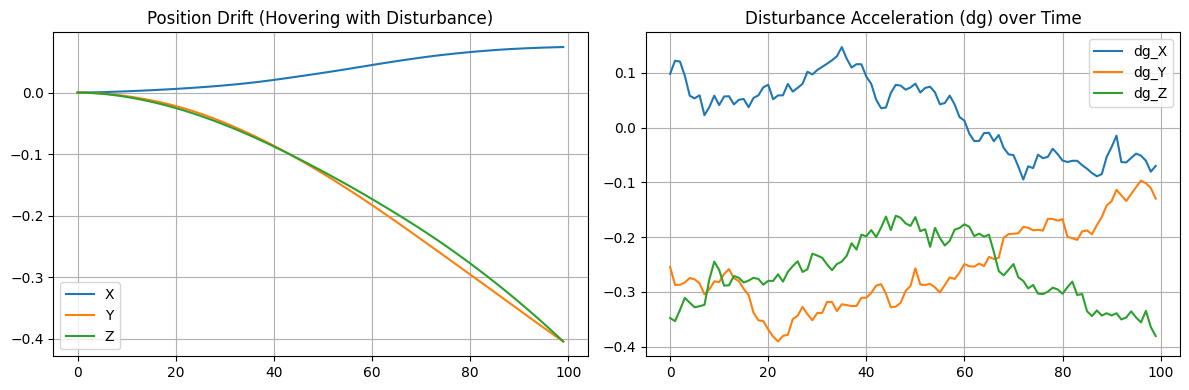

In [7]:
def update_dg(dg_curr: torch.Tensor, dt: float, noise_std: float = 0.2) -> torch.Tensor:
    """
    更新额外加速度 (Disturbance Gravity)。
    使用一阶马尔可夫过程 (Ornstein-Uhlenbeck Process 近似) 模拟随时间变化的扰动。
    
    Args:
        dg_curr (torch.Tensor): 当前的扰动向量 [B, 3]
        dt (float): 时间步长
        noise_std (float): 噪声标准差，控制扰动的幅度
        
    Returns:
        dg_new (torch.Tensor): 更新后的扰动向量
    """
    # 衰减系数，确保扰动不会无限增长，且保持时间相关性
    # 参考项目公式: dg = dg * sqrt(1 - dt/4) + noise * std * sqrt(dt/4)
    # 这是一种保持方差恒定的随机游走更新
    
    decay_factor = math.sqrt(1 - dt / 4.0)
    noise_factor = noise_std * math.sqrt(dt / 4.0)
    
    # 生成随机噪声
    noise = torch.randn_like(dg_curr)
    
    dg_new = dg_curr * decay_factor + noise * noise_factor
    return dg_new

# ==========================================
# 完整闭环仿真示例 (结合 dg)
# ==========================================
print("--- 测试带扰动的完整仿真循环 ---")

# 1. 初始化
B = 1
steps = 100
dt = 0.02

# 状态变量
p = torch.zeros((B, 3), device=device)       # 位置
v = torch.zeros((B, 3), device=device)       # 速度
a = torch.zeros((B, 3), device=device)       # 加速度
R = torch.eye(3, device=device).unsqueeze(0) # 姿态
act = torch.zeros((B, 3), device=device)     # 实际推力(加速度形式)
dg = torch.randn((B, 3), device=device) * 0.2 # 初始化扰动

# 期望控制量 (假设我们要悬停，只有重力补偿)

act_pred = torch.zeros((B, 3), device=device) # 期望合加速度为0 (悬停)

# 记录轨迹
traj_p = []
traj_dg = []

for i in range(steps):
    # 模拟一步动力学
    p, v, a, act = simulate_position_step(
        p, v, a, act, act_pred, R, dt, 
        dg=dg # 传入当前的 dg
    )
    
    # 更新扰动
    dg = update_dg(dg, dt)
    
    # 更新姿态 (这里简单假设姿态完美跟踪或者是根据某种策略更新)
    # 在这个简单的测试中，我们保持姿态不变(水平)，或者你可以加入姿态控制逻辑
    # 比如我们希望它稍微抵抗一点风，但这里我们先通过 update_dg 观察位置漂移
    
    traj_p.append(p.clone())
    traj_dg.append(dg.clone())

# 转换为 Tensor 方便绘图
traj_p = torch.stack(traj_p).squeeze(1).cpu()
traj_dg = torch.stack(traj_dg).squeeze(1).cpu()

print(f"仿真结束。最后位置: {p}")
print(f"位置漂移 (由于 dg): {p.norm()}")

# 简单的绘图 (如果有 matplotlib)
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(traj_p[:, 0], label='X')
    plt.plot(traj_p[:, 1], label='Y')
    plt.plot(traj_p[:, 2], label='Z')
    plt.title("Position Drift (Hovering with Disturbance)")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(traj_dg[:, 0], label='dg_X')
    plt.plot(traj_dg[:, 1], label='dg_Y')
    plt.plot(traj_dg[:, 2], label='dg_Z')
    plt.title("Disturbance Acceleration (dg) over Time")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib not found, skipping plot.")


仿真结束。最后位置: tensor([[-0.1551,  0.0218, -0.1177],
        [-0.0860, -0.2207, -0.0364],
        [-0.3970,  0.0203,  0.0543],
        [ 0.2938, -0.0673, -0.1000],
        [ 0.3388, -0.1896, -0.0837],
        [-0.1633,  0.3374, -0.0170],
        [-0.1118,  0.1063,  0.3285],
        [ 0.5914,  0.0207,  0.4575],
        [-0.2371, -0.6348, -0.2414],
        [-0.0875,  0.3355,  0.4676]], device='cuda:0')
位置漂移 (由于 dg): 1.4844800233840942


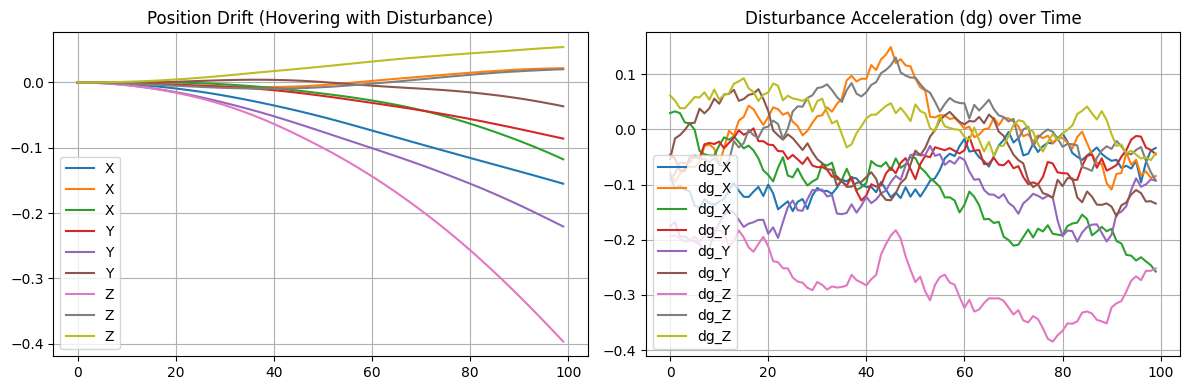

In [8]:
# 整理代码
import torch
import math

def solve_attitude_from_thrust_and_goal_vec(
    thrust_vector: torch.Tensor, 
    velocity: torch.Tensor, 
    R_old: torch.Tensor, 
    yaw_inertia: float = 5.0,
    dt: float = 0.02,
    yaw_ctl_delay: float = 12.0 # 建议默认值 12.0 (参考的DiffPhysDrone default)
) -> torch.Tensor:
    """
    根据期望推力向量和目标向量，反解机体姿态 (旋转矩阵)。
    支持单个输入或批量输入。
    
    Args:
        thrust_vector (torch.Tensor): 期望推力向量 (世界坐标系)，对应机体 Z 轴方向。Shape: (3,) or (B, 3)
        velocity (torch.Tensor): 指向目标的向量 (世界坐标系)，用于确定机头朝向。Shape: (3,) or (B, 3)
        R_old (torch.Tensor): 上一时刻的旋转矩阵 (Body to World)。Shape: (3, 3) or (B, 3, 3)
        yaw_inertia (float): 偏航惯性系数 (混合权重)。
        dt (float): 时间步长，用于计算平滑系数。
        yaw_ctl_delay (float): 偏航控制延迟/响应系数 (参考项目中的二级平滑参数)。
                               值越大响应越快 (alpha越小)。
        
    Returns:
        torch.Tensor: 新的旋转矩阵 R_new (Body to World)。Shape: (3, 3) or (B, 3, 3)
    """
    # 维度处理 (统一转为 Batch 模式)
    is_batch = True
    if thrust_vector.dim() == 1:
        is_batch = False
        thrust_vector = thrust_vector.unsqueeze(0) # [1, 3]
        velocity = velocity.unsqueeze(0)           # [1, 3]
        R_old = R_old.unsqueeze(0)                 # [1, 3, 3]
        
    # 确定机体 Z 轴 (Body Up)
    # Z 轴方向即为推力方向
    # normalize dim=1 (across x,y,z)
    z_new = torch.nn.functional.normalize(thrust_vector, dim=1)
    
    # 确定机体 X 轴 (Body Forward)
    # 逻辑：混合“旧的机头朝向”与“当前速度方向”，并强制与 Z 轴垂直
    
    # 获取旧的 X 轴 (R 的第一列)
    # R_old: [B, 3, 3] -> R_old[:, :, 0]: [B, 3]
    x_old = R_old[:, :, 0]
    
    # [一级平滑/混合] 混合向量 (基于 yaw_inertia)
    # 参考项目 Update: forward_vec = forward_vec * yaw_inertia + v_pred
    # 物理含义: 风向标效应。速度越大，对机头朝向的修正力越大。
    # 不进行归一化，自然处理低速/悬停情况
    f_mixed_raw = x_old * yaw_inertia + velocity
    
    # 计算目标朝向 (Heading)
    target_heading = torch.nn.functional.normalize(f_mixed_raw, dim=1)
    
    # [二级平滑] Exponential Smoothing (参考项目逻辑)
    # alpha = exp(-delay * dt). delay 越大 (响应越快), alpha 越小, 结果越接近 target.
    # f_temp = target * (1 - alpha) + old * alpha
    alpha = math.exp(-yaw_ctl_delay * dt)
    f_temp = target_heading * (1 - alpha) + x_old * alpha
    
    # 正交化 (Orthogonalization)
    # 约束: x_new . z_new = 0  =>  fx*ux + fy*uy + fz*uz = 0
    # 解法: 保留 f_temp 的 x, y 分量，计算 fz
    ux, uy, uz = z_new[:, 0], z_new[:, 1], z_new[:, 2]
    fx, fy = f_temp[:, 0], f_temp[:, 1]
    
    # 准备结果容器
    fz_new = torch.zeros_like(fx)
    
    # 避免除以零 (当机体 Z 轴完全水平时，uz=0)
    mask_stable = torch.abs(uz) > 1e-6
    
    # 正常情况计算
    if mask_stable.any():
        fz_new[mask_stable] = -(fx[mask_stable] * ux[mask_stable] + fy[mask_stable] * uy[mask_stable]) / uz[mask_stable]
        
    x_new_unnormalized = torch.stack([fx, fy, fz_new], dim=1)
    
    # 备选方案：如果 Z 轴水平 (uz 接近 0)，使用旧的 Y 轴与 Z 轴叉乘得到 X 轴
    if not mask_stable.all():
        y_old = R_old[:, :, 1]
        # cross product
        x_fallback = torch.cross(y_old, z_new, dim=1)
        x_new_unnormalized[~mask_stable] = x_fallback[~mask_stable]
        
    # 归一化得到新的 X 轴
    x_new = torch.nn.functional.normalize(x_new_unnormalized, dim=1)
    
    # 确定机体 Y 轴 (Body Left)
    # 右手定则: y = z cross x
    y_new = torch.cross(z_new, x_new, dim=1)
    
    # 组合旋转矩阵
    # 列向量分别为 X, Y, Z -> stack dim=2
    R_new = torch.stack([x_new, y_new, z_new], dim=2)
    
    # 如果输入不是 batch，还原维度
    if not is_batch:
        return R_new.squeeze(0)
        
    return R_new

def simulate_position_step(
    p: torch.Tensor,       # 当前位置 (World) [B, 3]
    v: torch.Tensor,       # 当前速度 (World) [B, 3]
    a: torch.Tensor,       # 上一时刻加速度 (World) [B, 3]
    act: torch.Tensor,     # 当前执行器状态 (Net Acceleration including Gravity) [B, 3]
    act_pred: torch.Tensor,# 期望执行器状态 (Net Acceleration including Gravity) [B, 3]
    R: torch.Tensor,       # 当前姿态 (Body to World) [B, 3, 3]
    dt: float,             # 时间步长
    # --- 环境与模型参数 ---
    dg: torch.Tensor = None,          # 重力扰动/外力 [B, 3]
    v_wind: torch.Tensor = None,      # 风速 (World) [B, 3]
    drag_coef_lin: float = 0.375,     # 线性阻力系数
    drag_coef_quad: float = 0.0,      # 二次阻力系数
    z_drag_coef: float = 1.0,         # Z轴阻力倍率 (模拟旋翼下洗气流影响)
    pitch_ctl_delay: float = 12.0,    # 姿态/推力响应延迟系数
    rotor_drag_coef: float = 0.07,    # 螺旋桨诱导阻力系数 (Propeller Induced Drag / H-force)
    airmode_coef: float = 0.5,        # [New] Airmode 系数 (参考项目默认 0.5)
    enable_airmode: bool = True,      # [New] Airmode 开关, 默认开启以对齐CUDA版
    enable_induced_drag: bool = False # [New] 诱导阻力开关, 默认关闭以对齐CUDA版
):
    """
    模拟单步位置和速度更新 (基于 DiffPhysDrone 动力学模型)。
    
    Args:
        p, v, a: 当前时刻的运动状态 (世界坐标系)
        act: 当前实际产生的合加速度 (包含重力)
        act_pred: 控制器期望产生的合加速度 (包含重力)
        R: 机体姿态旋转矩阵
        dt: 仿真步长
        # --- 环境与模型参数 ---
        dg: 外部扰动
        v_wind: 风速
        drag_coef_lin: 线性阻力系数
        drag_coef_quad: 二次阻力系数
        z_drag_coef: Z轴阻力倍率
        pitch_ctl_delay: 推力响应延迟系数
        rotor_drag_coef: 螺旋桨诱导阻力系数
        airmode_coef: Airmode AV induced acceleration coefficient
        enable_airmode: Enable Airmode simulation (AV induced acceleration)
        enable_induced_drag: Enable Propeller Induced Drag (H-force)
    Returns:
        p_next, v_next, a_next, act_next
    """
    # 1. 执行器动力学 (低通滤波模拟延迟)
    # alpha = exp(-delay * dt)
    alpha = math.exp(-pitch_ctl_delay * dt)
    act_next = act_pred * (1 - alpha) + act * alpha
    
    # 2. 阻力计算 (Drag)
    # 相对速度
    if v_wind is None:
        v_rel = v
    else:
        v_rel = v - v_wind
        
    # 将相对速度投影到机体坐标系 (Body Frame)
    # v_body = v_rel @ R  (注意 R 是 Body->World, 所以 v_rel @ R 相当于 v_rel . col_i)
    # R 的列向量分别是 Body 的 X, Y, Z 轴在 World 下的表示
    # v_fwd (X) = v_rel . X_axis
    # v_left (Y) = v_rel . Y_axis
    # v_up (Z) = v_rel . Z_axis
    
    # 批量矩阵乘法: v_rel [B, 3], R [B, 3, 3]
    # v_rel.unsqueeze(1) [B, 1, 3] @ R [B, 3, 3] -> [B, 1, 3]
    v_body = torch.bmm(v_rel.unsqueeze(1), R).squeeze(1)
    
    v_fwd = v_body[:, 0]
    v_left = v_body[:, 1]
    v_up = v_body[:, 2]
    
    # 计算带符号的平方项 (用于二次阻力)
    v_fwd_2 = v_fwd * torch.abs(v_fwd)
    v_left_2 = v_left * torch.abs(v_left)
    v_up_2 = v_up * torch.abs(v_up)
    
    # 计算阻力加速度 (在机体坐标系下计算分量，然后合成到世界坐标系)
    # 线性阻力分量
    a_drag_lin_body = torch.stack([
        v_fwd, 
        v_left, 
        v_up * z_drag_coef
    ], dim=1)
    
    # 二次阻力分量
    a_drag_quad_body = torch.stack([
        v_fwd_2, 
        v_left_2, 
        v_up_2 * z_drag_coef
    ], dim=1)
        
    # 转换回世界坐标系
    # a_drag_world = R @ a_drag_body.T -> [B, 3, 3] @ [B, 3, 1]
    a_drag_lin_world = torch.bmm(R, a_drag_lin_body.unsqueeze(2)).squeeze(2)
    a_drag_quad_world = torch.bmm(R, a_drag_quad_body.unsqueeze(2)).squeeze(2)
    
    # 常规气动阻力
    a_drag = a_drag_lin_world * drag_coef_lin + a_drag_quad_world * drag_coef_quad
    
    # [New] 3. 螺旋桨诱导阻力 (Propeller Induced Drag / H-force)
    # 仅当 enable_induced_drag=True 时计算
    a_drag_induced = torch.zeros_like(act_next)
    
    if enable_induced_drag:
        # 计算推力向量 (去除重力, 假设 Z 轴向下为负, g_std=[0,0,-9.8])
        # act_next = Thrust + Disturbance + Gravity. 
        # 这里近似认为 act_next 代表了当前的合力状态，从中提取 Thrust magnitude
        # 假设标准重力
        g_vec = torch.tensor([0.0, 0.0, -9.80665], device=act.device)
        thrust_acc_vec = act_next - g_vec # [B, 3]
        thrust_mag = torch.norm(thrust_acc_vec, dim=1) # [B]
        
        # 电机速度估算 (sqrt of thrust)
        motor_vel = torch.sqrt(torch.clamp(thrust_mag, min=1e-6))
        
        # 计算垂直于推力方向的速度 (v_prep)
        # v_perp_body = [v_fwd, v_left, 0]
        # 诱导阻力主要作用在水平面 (机体 XY 平面)
        a_drag_induced_body = torch.stack([
            v_fwd * motor_vel * z_drag_coef, # Apply z_drag_coef as scaling
            v_left * motor_vel * z_drag_coef,
            torch.zeros_like(v_up)
        ], dim=1)
        
        # 变换回世界坐标系
        a_drag_induced_world = torch.bmm(R, a_drag_induced_body.unsqueeze(2)).squeeze(2)
        
        # 应用诱导阻力系数
        a_drag_induced = a_drag_induced_world * rotor_drag_coef
    
    # [New] 4. Airmode (Angular Velocity Induced Acceleration)
    # 仅当 enable_airmode=True 时计算
    a_airmode = torch.zeros_like(act_next)
    
    if enable_airmode:
        # 计算 act 与 act_next 之间的夹角 (用于估算角速度 av)
        # 参考项目逻辑：scalar_t dot = act... * act_next...;
        # scalar_t av = acos(max(-1., min(1., dot / max(1e-8, sqrt(n1) * sqrt(n2))))) / ctl_dt;
        
        # 范数计算 (避免除零)
        n1 = torch.norm(act, dim=1, keepdim=True)
        n2 = torch.norm(act_next, dim=1, keepdim=True)
        n1 = torch.clamp(n1, min=1e-8)
        n2 = torch.clamp(n2, min=1e-8)
        
        # 点积
        dot = torch.sum(act * act_next, dim=1, keepdim=True)
        
        # 夹角
        cos_theta = torch.clamp(dot / (n1 * n2), min=-1.0, max=1.0)
        angle = torch.acos(cos_theta) # [B, 1]
        
        # 角速度近似
        av = angle / dt 
        
        # 计算额外加速度
        # 参考项目: airmode_a axes = ax/thrust * av * airmode_av2a
        # 方向：沿当前推力方向 (act)
        # 注意: act 包含重力，参考项目中使用的是包含重力的合向量计算的方向，我们也保持一致
        dir_vec = act / n1
        
        a_airmode = dir_vec * av * airmode_coef

    # 5. 合加速度计算
    # a_next = Thrust_acc + Gravity + Disturbance - Drag - Induced_Drag + Airmode
    if dg is None:
        dg = torch.zeros_like(act_next)
        
    a_next = act_next + dg - a_drag - a_drag_induced + a_airmode
    
    # 6. 积分更新 (Velocity Verlet / Trapezoidal)
    # p_next = p + v * dt + 0.5 * a * dt^2
    p_next = p + v * dt + 0.5 * a * dt**2
    
    # v_next = v + 0.5 * (a + a_next) * dt
    v_next = v + 0.5 * (a + a_next) * dt
    
    return p_next, v_next, a_next, act_next

def update_dg(dg_curr: torch.Tensor, dt: float, noise_std: float = 0.2) -> torch.Tensor:
    """
    更新额外加速度 (Disturbance Gravity)。
    使用一阶马尔可夫过程 (Ornstein-Uhlenbeck Process 近似) 模拟随时间变化的扰动。
    
    Args:
        dg_curr (torch.Tensor): 当前的扰动向量 [B, 3]
        dt (float): 时间步长
        noise_std (float): 噪声标准差，控制扰动的幅度
        
    Returns:
        dg_new (torch.Tensor): 更新后的扰动向量
    """
    # 衰减系数，确保扰动不会无限增长，且保持时间相关性
    # 参考项目公式: dg = dg * sqrt(1 - dt/4) + noise * std * sqrt(dt/4)
    # 这是一种保持方差恒定的随机游走更新
    
    decay_factor = math.sqrt(1 - dt / 4.0)
    noise_factor = noise_std * math.sqrt(dt / 4.0)
    
    # 生成随机噪声
    noise = torch.randn_like(dg_curr)
    
    dg_new = dg_curr * decay_factor + noise * noise_factor
    return dg_new

# ==========================================
# 一个批量处理示范过程


# 1. 初始化
B = 10
steps = 100
dt = 0.02

# 状态变量
p = torch.zeros((B, 3), device=device)       # 位置
v = torch.zeros((B, 3), device=device)       # 速度
a = torch.zeros((B, 3), device=device)       # 加速度
R = torch.eye(3, device=device).unsqueeze(0).repeat(B, 1, 1) # 姿态
act = torch.zeros((B, 3), device=device)     # 实际推力(加速度形式)
dg = torch.randn((B, 3), device=device) * 0.2 # 初始化扰动

# 期望控制量 (假设我们要悬停，只有重力补偿)

act_pred = torch.zeros((B, 3), device=device) # 期望合加速度为0 (悬停)

# 记录轨迹
traj_p = []
traj_dg = []

for i in range(steps):
    # 模拟一步动力学
    # 可以在这里控制 enable_airmode 和 enable_induced_drag
    p, v, a, act = simulate_position_step(
        p, v, a, act, act_pred, R, dt, 
        dg=dg, # 传入当前的 dg
        enable_airmode=True,       # 开启 Airmode
        enable_induced_drag=False  # 关闭 H-force (默认配置)
    )
    
    # 更新扰动
    dg = update_dg(dg, dt)
    
    # 更新姿态 (这里简单假设姿态完美跟踪或者是根据某种策略更新)
    # 在这个简单的测试中，我们保持姿态不变(水平)，或者你可以加入姿态控制逻辑
    # 比如我们希望它稍微抵抗一点风，但这里我们先通过 update_dg 观察位置漂移
    
    traj_p.append(p.clone())
    traj_dg.append(dg.clone())

# 转换为 Tensor 方便绘图
traj_p = torch.stack(traj_p).squeeze(1).cpu()
traj_dg = torch.stack(traj_dg).squeeze(1).cpu()

print(f"仿真结束。最后位置: {p}")
print(f"位置漂移 (由于 dg): {p.norm()}")

# 简单的绘图 (如果有 matplotlib)
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(traj_p[:, 0], label='X')
    plt.plot(traj_p[:, 1], label='Y')
    plt.plot(traj_p[:, 2], label='Z')
    plt.title("Position Drift (Hovering with Disturbance)")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(traj_dg[:, 0], label='dg_X')
    plt.plot(traj_dg[:, 1], label='dg_Y')
    plt.plot(traj_dg[:, 2], label='dg_Z')
    plt.title("Disturbance Acceleration (dg) over Time")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib not found, skipping plot.")

# 这里还缺一个从我们假设的世界坐标系上变换到Pytorch3D world坐标上的转换器。以及把Pytorch3D坐标转换到我们假设的world坐标系上的函数（最好是批量的）

In [12]:

# ==========================================
# 坐标系转换验证
# ==========================================
import torch

def transform_pos_ros2pt3d(pos):
    """
    将位置向量从 ROS (ENU) 坐标系转换到 PyTorch3D 渲染坐标系。
    
    ROS (ENU): 
        +X: East
        +Y: North
        +Z: Up
    PyTorch3D: 
        +X: Left
        +Y: Up
        +Z: In (Screen)
        
    Mapping:
        ROS East (+X)  -> PyTorch3D Right (-X)
        ROS North (+Y) -> PyTorch3D In (+Z)
        ROS Up (+Z)    -> PyTorch3D Up (+Y)
        
    Formula:
        (x, y, z) -> (-x, z, y)
    """
    x = pos[..., 0]
    y = pos[..., 1]
    z = pos[..., 2]
    return torch.stack([-x, z, y], dim=-1)

def transform_rot_ros2pt3d(R):
    """
    将旋转矩阵 (Body -> World) 从 ROS 坐标系转换到 PyTorch3D 坐标系。
    假设 Body Frame 在两种定义下相对网格是一致的 (Mesh is static).
    
    R_pt3d = T_coord @ R_ros
    """
    # R: [..., 3, 3]
    # 变换基向量 (R 的列向量)
    r0 = transform_pos_ros2pt3d(R[..., 0]) # Body X axis in Pt3D World
    r1 = transform_pos_ros2pt3d(R[..., 1]) # Body Y axis in Pt3D World
    r2 = transform_pos_ros2pt3d(R[..., 2]) # Body Z axis in Pt3D World
    return torch.stack([r0, r1, r2], dim=-1)

# 测试代码
if __name__ == "__main__":
    # 1. 简单位置测试
    p_ros = torch.tensor([1.0, 2.0, 3.0]) # East=1, North=2, Up=3
    p_pt3d = transform_pos_ros2pt3d(p_ros)
    print(f"Pos ROS: {p_ros}")
    print(f"Pos PyTorch3D: {p_pt3d}") # Expect [-1, 3, 2]
    
    # 2. 旋转矩阵测试 (Identity)
    # 此时机体对齐世界: Body Front=East, Body Left=North, Body Up=Up
    R_ros = torch.eye(3)
    R_pt3d = transform_rot_ros2pt3d(R_ros)
    print(f"\nR ROS (Identity): \n{R_ros}")
    print(f"R PyTorch3D: \n{R_pt3d}") 
    # Expect: Col0=[-1, 0, 0] (Right), Col1=[0, 0, 1] (In), Col2=[0, 1, 0] (Up)
    
    # 3. 旋转测试 (Yaw 90 deg)
    # 机头朝北 (North). 
    # ROS: Rotated 90 deg around Z.
    # New X = Y_old (North) = [0, 1, 0]
    # New Y = -X_old (West) = [-1, 0, 0]
    # New Z = Z_old (Up) = [0, 0, 1]
    R_ros_90 = torch.tensor([
        [0.0, -1.0, 0.0],
        [1.0,  0.0, 0.0],
        [0.0,  0.0, 1.0]
    ])
    R_pt3d_90 = transform_rot_ros2pt3d(R_ros_90)
    print(f"\nR ROS (Yaw 90): \n{R_ros_90}")
    print(f"R PyTorch3D (Yaw 90): \n{R_pt3d_90}")
    # Body Front is now North. In Pt3D, North is +Z (In). So Col0 should be [0, 0, 1].
    # Body Left is now West. West is -East. East is Right (-X). West is Left (+X). So Col1 should be [1, 0, 0].
    # Body Up is Up (+Y). Col2 should be [0, 1, 0].


Pos ROS: tensor([1., 2., 3.])
Pos PyTorch3D: tensor([-1.,  3.,  2.])

R ROS (Identity): 
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
R PyTorch3D: 
tensor([[-1., -0., -0.],
        [ 0.,  0.,  1.],
        [ 0.,  1.,  0.]])

R ROS (Yaw 90): 
tensor([[ 0., -1.,  0.],
        [ 1.,  0.,  0.],
        [ 0.,  0.,  1.]])
R PyTorch3D (Yaw 90): 
tensor([[-0., 1., -0.],
        [0., 0., 1.],
        [1., 0., 0.]])
